In [1]:
print("""
@File         : performing_multivariate_imputation_by_chained_equations.ipynb
@Author(s)    : Stephen CUI
@LastEditor(s): Stephen CUI
@CreatedTime  : 2025-01-26 22:20:20
@Email        : cuixuanstephen@gmail.com
@Description  : 通过链式方程进行多元插补
""")


@File         : performing_multivariate_imputation_by_chained_equations.ipynb
@Author(s)    : Stephen CUI
@LastEditor(s): Stephen CUI
@CreatedTime  : 2025-01-26 22:20:20
@Email        : cuixuanstephen@gmail.com
@Description  : 通过链式方程进行多元插补



与单变量插补相反，多元插补方法使用多个变量来估计缺失值。链式方程多元插补 (Multivariate Imputation by Chained Equations, MICE) 将每个具有缺失值的变量建模为数据集中其余变量的函数。该函数的输出用于替换缺失数据。

MICE 涉及以下步骤：
1. 首先，它对每个有缺失数据的变量进行简单的单变量插补。例如，中位数插补;
2. 接下来，它选择一个特定的变量，比如 `var_1`，并将缺失值设置回缺失；
3. 它训练模型使用其他变量作为输入特征来预测 `var_1`；
4. 最后，用模型的输出替换 `var_1` 的缺失值。

MICE 对剩余的每个变量重复步骤 2 到 4。一旦所有变量都已建模，一个归纳循环就结束了。MICE 会进行多个归纳循环，通常为 10 个。也就是说，我们对每个变量重复 10 次步骤 2 到 4。这样做的目的是，到循环结束时，我们应该已经找到了每个变量缺失数据的最佳估计值。

> 当我们不想扭曲变量分布时，多元插补可以作为单变量插补的有用替代方法。当我们想要对缺失数据进行良好的估计时，多元插补也很有用。

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import BayesianRidge
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer, SimpleImputer

In [3]:
variables = [
    "A2", "A3", "A8", "A11", "A14", "A15", "target"]
data = pd.read_csv(
    "../../DATA/credit_approval_uci.csv",
    usecols=variables)

In [4]:
X_train, X_test, y_train, y_test = train_test_split(
    data.drop("target", axis=1),
    data["target"],
    test_size=0.3,
    random_state=0,
)

In [5]:
imputer = IterativeImputer(
    estimator=BayesianRidge(),
    max_iter=10, random_state=0
).set_output(transform='pandas')

> `IterativeImputer()` 包含其他有用的参数。例如，我们可以使用 `initial_strategy` 参数指定第一个插补策略。我们可以从平均值、中位数、众数或任意插补中进行选择。我们还可以指定如何循环变量，无论是随机循环还是从缺失值最少的变量到缺失值最多的变量。

In [6]:
imputer.fit(X_train)

IterativeImputer(estimator=BayesianRidge(), random_state=0)

In [7]:
X_train_t = imputer.transform(X_train)
X_test_t = imputer.transform(X_test)

为了总结一下，让我们用一个简单的单变量插补方法来插补变量，并比较对变量分布的影响。

In [14]:
imputer_simple = SimpleImputer(
    strategy='mean'
).set_output(transform='pandas')

X_train_s = imputer_simple.fit_transform(X_train)
X_test_s = imputer_simple.transform(X_test)

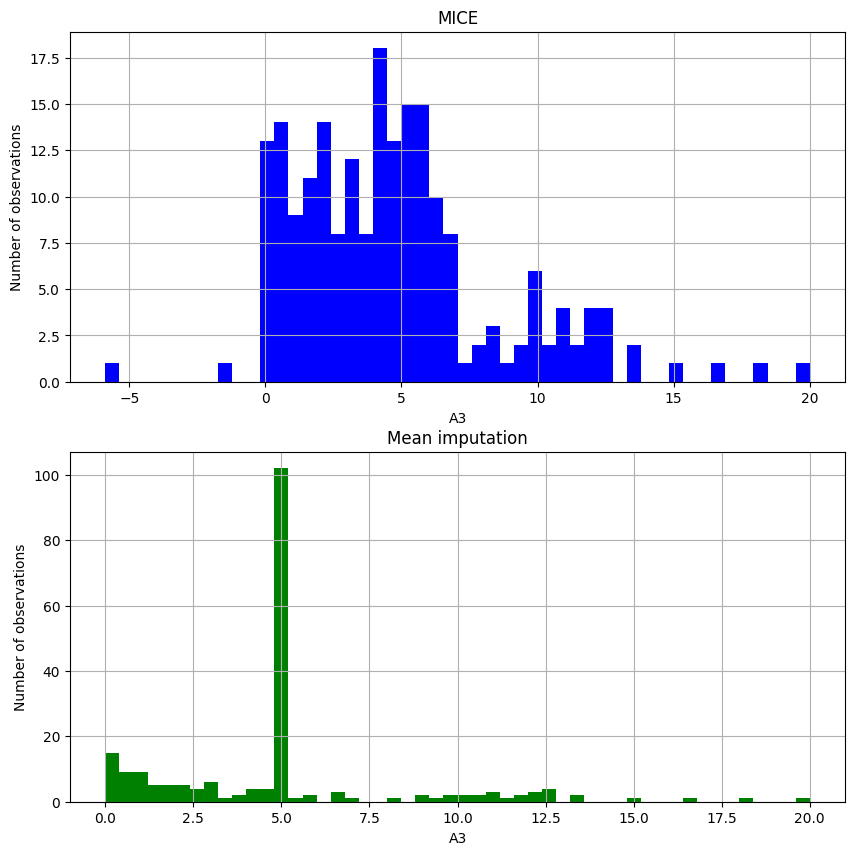

In [15]:
fig, axes = plt.subplots(2, 1, figsize=(10, 10), squeeze=False)

X_test_t['A3'].hist(bins=50, ax=axes[0, 0], color='blue')
X_test_s["A3"].hist(bins=50, ax=axes[1, 0], color="green")
axes[0, 0].set_ylabel('Number of observations')
axes[1, 0].set_ylabel('Number of observations')
axes[0, 0].set_xlabel('A3')
axes[1, 0].set_xlabel('A3')
axes[0, 0].set_title('MICE')
axes[1, 0].set_title('Mean imputation')
plt.show()

> IterativeImputer() 只能基于数值变量估算数值变量中的缺失数据。如果要使用分类变量作为输入，则需要先对其进行编码。但是，请记住，它只会进行回归。因此，它不适合估计离散或分类变量中的缺失数据。